In [1]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 12.5 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


/Applications/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [15:15:13] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Classification Report ===
              precision    recall  f1-score   support

         0.0       0.93      0.94      0.93        97
         1.0       0.40      0.36      0.38        11

    accuracy                           0.88       108
   macro avg       0.66      0.65      0.66       108
weighted avg       0.87      0.88      0.88       108


=== Sample Predictions with Permalinks ===
                    company_permalink  actual_target  predicted_target
789      /company/presage-biosciences            0.0                 0
407                  /company/glympse            0.0                 0
673       /company/nano3d-biosciences            0.0                 1
455                 /company/homesnap            0.0                 0
736     /company/oyster-hotel-reviews            0.0                 0
65   /company/apellis-pharmaceuticals            0.0                 0
611            /company/mavenlink-com            0.0                 0
415            /company/grab-n

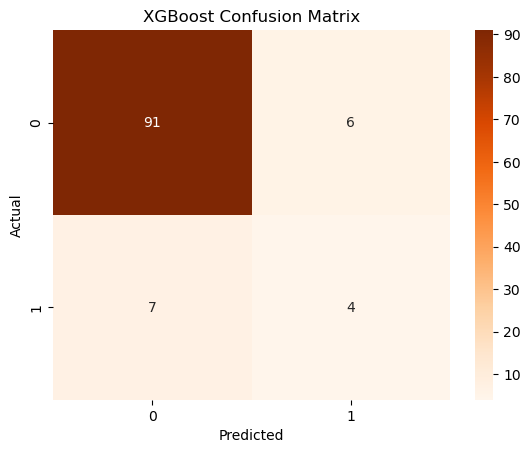

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier

# Step 1: Load data
df = pd.read_csv("/Users/macbook/Downloads/Preprocessed_training_data_v1.csv")

# Step 2: Filter rows 0–200 and 400–800
filtered_df = pd.concat([df.iloc[0:201], df.iloc[400:801]])

# Step 3: Drop rows with missing values
filtered_clean = filtered_df.dropna()

# Step 4: Setup X and y
permalinks = filtered_clean['company_permalink']
y = filtered_clean['target']
X = filtered_clean.drop(columns=['company_permalink', 'target'])
X = X.select_dtypes(include='number')

# Step 5: Train/test split
X_train, X_test, y_train, y_test, permalinks_train, permalinks_test = train_test_split(
    X, y, permalinks, test_size=0.2, random_state=42, stratify=y)

# Step 6: Calculate scale_pos_weight (to balance classes)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Step 7: Train XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train, y_train)

# Step 8: Predict and evaluate
y_pred = xgb.predict(X_test)
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Step 9: Permalink result view
results_df = pd.DataFrame({
    'company_permalink': permalinks_test,
    'actual_target': y_test,
    'predicted_target': y_pred
})
print("\n=== Sample Predictions with Permalinks ===")
print(results_df.head(15))

# Step 10: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix')
plt.show()